In [1]:
# Copyright (c) 2023 NVIDIA Corporation & Affiliates. All rights reserved.
#
# Permission is hereby granted, free of charge, to any person obtaining
# a copy of this software and associated documentation files
# (the "Software"), to deal in the Software without restriction,
# including without limitation the rights to use, copy, modify, merge,
# publish, distribute, sublicense, and/or sell copies of the Software,
# and to permit persons to whom the Software is furnished to do so,
# subject to the following conditions:
#
# The above copyright notice and this permission notice shall be
# included in all copies or substantial portions of the Software.
#
# THE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND,
# EXPRESS OR IMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF
# MERCHANTABILITY, FITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT.
# IN NO EVENT SHALL THE AUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY
# CLAIM, DAMAGES OR OTHER LIABILITY, WHETHER IN AN ACTION OF CONTRACT,
# TORT OR OTHERWISE, ARISING FROM, OUT OF OR IN CONNECTION WITH THE
# SOFTWARE OR THE USE OR OTHER DEALINGS IN THE SOFTWARE.


import torch


import triton
import triton.language as tl






In [2]:
@triton.autotune(
    configs=[
        triton.Config({
            'BLOCK_SIZE_M': 128,
            'BLOCK_SIZE_N': 128,
            'BLOCK_SIZE_K': 32,
            'NUM_SM': 84,
        }),
        triton.Config({
            'BLOCK_SIZE_M': 128,
            'BLOCK_SIZE_N': 128,
            'BLOCK_SIZE_K': 32,
            'NUM_SM': 128,
        }),
        triton.Config({
            'BLOCK_SIZE_M': 64,
            'BLOCK_SIZE_N': 64,
            'BLOCK_SIZE_K': 32,
            'NUM_SM': 84,
        }),
        triton.Config({
            'BLOCK_SIZE_M': 64,
            'BLOCK_SIZE_N': 64,
            'BLOCK_SIZE_K': 32,
            'NUM_SM': 128,
        }),
    ],
    key=['group_size'],
)
@triton.jit
def grouped_matmul_kernel(
    # device tensor of matrices pointers
    # 设备张量矩阵指针
    group_a_ptrs,
    group_b_ptrs,
    group_c_ptrs,
    # device tensor of gemm sizes. its shape is [group_size, 3]
    # 设备张量的 GEMM（General Matrix Multiply）大小。其形状为 [group_size, 3]
    # dim 0 is group_size, dim 1 is the values of <M, N, K> of each gemm
    # 第 0 维是 group_size，第 1 维是每个 GEMM 的 <M, N, K> 值
    group_gemm_sizes,
    # device tensor of leading dimension sizes. its shape is [group_size, 3]
    # 设备张量的主导维度大小。其形状为 [group_size, 3]
    # dim 0 is group_size, dim 1 is the values of <lda, ldb, ldc> of each gemm
    # 第 0 维是 group_size，第 1 维是每个 GEMM 的 <lda, ldb, ldc> 值
    g_lds,
    # number of gemms
    # gemms 数量
    group_size,
    # number of virtual SM
    # 虚拟 SM 数量
    NUM_SM: tl.constexpr,
    # tile sizes
    # tile 大小
    BLOCK_SIZE_M: tl.constexpr,
    BLOCK_SIZE_N: tl.constexpr,
    BLOCK_SIZE_K: tl.constexpr,
):
    tile_idx = tl.program_id(0)
    last_problem_end = 0
    for g in range(group_size):
        # get the gemm size of the current problem
        # 得到当前问题的 gemm 大小
        gm = tl.load(group_gemm_sizes + g * 3)
        gn = tl.load(group_gemm_sizes + g * 3 + 1)
        gk = tl.load(group_gemm_sizes + g * 3 + 2)
        num_m_tiles = tl.cdiv(gm, BLOCK_SIZE_M)
        num_n_tiles = tl.cdiv(gn, BLOCK_SIZE_N)
        num_tiles = num_m_tiles * num_n_tiles
        # iterate through the tiles in the current gemm problem
        # 迭代当前 GEMM 问题中的 tiles
        while (tile_idx >= last_problem_end and tile_idx < last_problem_end + num_tiles):
            # pick up a tile from the current gemm problem
            # 从当前 GEMM 问题选择一个 title
            k = gk
            lda = tl.load(g_lds + g * 3)
            ldb = tl.load(g_lds + g * 3 + 1)
            ldc = tl.load(g_lds + g * 3 + 2)
            a_ptr = tl.load(group_a_ptrs + g).to(tl.pointer_type(tl.float16))
            b_ptr = tl.load(group_b_ptrs + g).to(tl.pointer_type(tl.float16))
            c_ptr = tl.load(group_c_ptrs + g).to(tl.pointer_type(tl.float16))
            # figure out tile coordinates
            # 确定 title 坐标
            tile_idx_in_gemm = tile_idx - last_problem_end
            tile_m_idx = tile_idx_in_gemm // num_n_tiles
            tile_n_idx = tile_idx_in_gemm % num_n_tiles


            # do regular gemm here
            # 此处进行常规 gemm
            offs_am = tile_m_idx * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)
            offs_bn = tile_n_idx * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)
            offs_k = tl.arange(0, BLOCK_SIZE_K)
            a_ptrs = a_ptr + offs_am[:, None] * lda + offs_k[None, :]
            b_ptrs = b_ptr + offs_k[:, None] * ldb + offs_bn[None, :]
            accumulator = tl.zeros((BLOCK_SIZE_M, BLOCK_SIZE_N), dtype=tl.float32)
            for kk in range(0, tl.cdiv(k, BLOCK_SIZE_K)):
                # hint to Triton compiler to do proper loop pipelining
                # 提示 Triton 编译器进行适当的循环流水线处理
                tl.multiple_of(a_ptrs, [16, 16])
                tl.multiple_of(b_ptrs, [16, 16])
                # assume full tile for now
                # 现在假设完整的 tile
                a = tl.load(a_ptrs)
                b = tl.load(b_ptrs)
                accumulator += tl.dot(a, b)
                a_ptrs += BLOCK_SIZE_K
                b_ptrs += BLOCK_SIZE_K * ldb
            c = accumulator.to(tl.float16)


            offs_cm = tile_m_idx * BLOCK_SIZE_M + tl.arange(0, BLOCK_SIZE_M)
            offs_cn = tile_n_idx * BLOCK_SIZE_N + tl.arange(0, BLOCK_SIZE_N)
            c_ptrs = c_ptr + ldc * offs_cm[:, None] + offs_cn[None, :]


            # assumes full tile for now
            # 现在假设完整的 tile
            tl.store(c_ptrs, c)


            # go to the next tile by advancing NUM_SM
            # 通过增加 NUM_SM 来进入下一个 tile
            tile_idx += NUM_SM


        # get ready to go to the next gemm problem
        # 准备进入下一个 gemm 问题
        last_problem_end = last_problem_end + num_tiles




def group_gemm_fn(group_A, group_B):
    device = torch.device('cuda')
    assert len(group_A) == len(group_B)
    group_size = len(group_A)


    A_addrs = []
    B_addrs = []
    C_addrs = []
    g_sizes = []
    g_lds = []
    group_C = []
    for i in range(group_size):
        A = group_A[i]
        B = group_B[i]
        assert A.shape[1] == B.shape[0]
        M, K = A.shape
        K, N = B.shape
        C = torch.empty((M, N), device=device, dtype=A.dtype)
        group_C.append(C)
        A_addrs.append(A.data_ptr())
        B_addrs.append(B.data_ptr())
        C_addrs.append(C.data_ptr())
        g_sizes += [M, N, K]
        g_lds += [A.stride(0), B.stride(0), C.stride(0)]


    # note these are device tensors
    # 注意这些是设备张量
    d_a_ptrs = torch.tensor(A_addrs, device=device)
    d_b_ptrs = torch.tensor(B_addrs, device=device)
    d_c_ptrs = torch.tensor(C_addrs, device=device)
    d_g_sizes = torch.tensor(g_sizes, dtype=torch.int32, device=device)
    d_g_lds = torch.tensor(g_lds, dtype=torch.int32, device=device)
    # we use a fixed number of CTA, and it's auto-tunable
    # 我们使用固定数量的 CTA（线程块），并且它是自动可调节的
    grid = lambda META: (META['NUM_SM'], )
    grouped_matmul_kernel[grid](
        d_a_ptrs,
        d_b_ptrs,
        d_c_ptrs,
        d_g_sizes,
        d_g_lds,
        group_size,
    )


    return group_C






In [3]:
group_m = [1024, 512, 256, 128]
group_n = [1024, 512, 256, 128]
group_k = [1024, 512, 256, 128]
group_A = []
group_B = []
assert len(group_m) == len(group_n)
assert len(group_n) == len(group_k)
group_size = len(group_m)
for i in range(group_size):
    M = group_m[i]
    N = group_n[i]
    K = group_k[i]
    A = torch.rand((M, K), device="cuda", dtype=torch.float16)
    B = torch.rand((K, N), device="cuda", dtype=torch.float16)
    group_A.append(A)
    group_B.append(B)


tri_out = group_gemm_fn(group_A, group_B)
ref_out = [torch.matmul(a, b) for a, b in zip(group_A, group_B)]
for i in range(group_size):
    assert torch.allclose(ref_out[i], tri_out[i], atol=1e-2, rtol=0)




# only launch the kernel, no tensor preparation here to remove all overhead
# 只启动内核，这里不进行张量准备，以移除所有开销。
def triton_perf_fn(a_ptrs, b_ptrs, c_ptrs, sizes, lds, group_size):
    grid = lambda META: (META['NUM_SM'], )
    grouped_matmul_kernel[grid](
        a_ptrs,
        b_ptrs,
        c_ptrs,
        sizes,
        lds,
        group_size,
    )




def torch_perf_fn(group_A, group_B):
    for a, b in zip(group_A, group_B):
        torch.matmul(a, b)






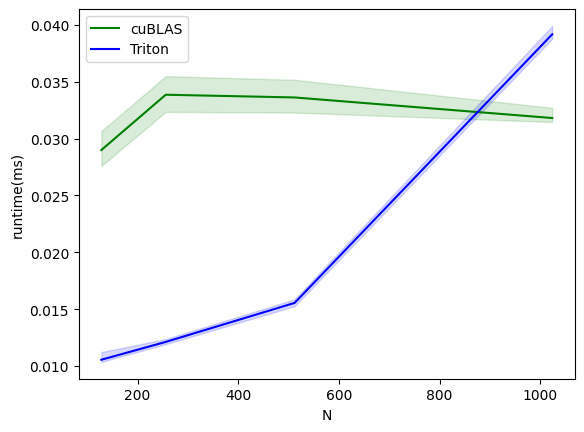

group-gemm-performance:
        N    cuBLAS    Triton
0   128.0  0.028992  0.010560
1   256.0  0.033856  0.012128
2   512.0  0.033616  0.015552
3  1024.0  0.031808  0.039168


In [4]:
@triton.testing.perf_report(
    triton.testing.Benchmark(
        # argument names to use as an x-axis for the plot
        # 用作绘图 x 轴的参数名称
        x_names=['N'],
        x_vals=[2**i for i in range(7, 11)],  # different possible values for `x_name` `x_name` 可能的不同取值
        line_arg='provider',
        # argument name whose value corresponds to a different line in the plot 参数名称，其值对应绘图中的不同线条
        # possible values for `line_arg``
        # `line_arg` 的可能取值
        line_vals=['cublas', 'triton'],
        # label name for the lines
        # 线条的标签名称
        line_names=["cuBLAS", "Triton"],
        # line styles
        # 线条样式
        styles=[('green', '-'), ('blue', '-')],
        ylabel="runtime(ms)",  # label name for the y-axis y 轴标签名称
        plot_name="group-gemm-performance",
        # name for the plot. Used also as a file name for saving the plot.
        # 绘图的名称。同时也作为保存绘图的文件名使用。
        args={},
    ))
def benchmark(N, provider):
    group_size = 4
    group_A = []
    group_B = []
    A_addrs = []
    B_addrs = []
    C_addrs = []
    g_sizes = []
    g_lds = []
    group_C = []
    for i in range(group_size):
        A = torch.rand((N, N), device="cuda", dtype=torch.float16)
        B = torch.rand((N, N), device="cuda", dtype=torch.float16)
        C = torch.empty((N, N), device="cuda", dtype=torch.float16)
        group_A.append(A)
        group_B.append(B)
        group_C.append(C)
        A_addrs.append(A.data_ptr())
        B_addrs.append(B.data_ptr())
        C_addrs.append(C.data_ptr())
        g_sizes += [N, N, N]
        g_lds += [N, N, N]


    d_a_ptrs = torch.tensor(A_addrs, device="cuda")
    d_b_ptrs = torch.tensor(B_addrs, device="cuda")
    d_c_ptrs = torch.tensor(C_addrs, device="cuda")
    d_g_sizes = torch.tensor(g_sizes, dtype=torch.int32, device="cuda")
    d_g_lds = torch.tensor(g_lds, dtype=torch.int32, device="cuda")


    quantiles = [0.5, 0.2, 0.8]
    if provider == 'cublas':
        ms, min_ms, max_ms = triton.testing.do_bench(lambda: torch_perf_fn(group_A, group_B), quantiles=quantiles)
    if provider == 'triton':
        ms, min_ms, max_ms = triton.testing.do_bench(
            lambda: triton_perf_fn(d_a_ptrs, d_b_ptrs, d_c_ptrs, d_g_sizes, d_g_lds, group_size), quantiles=quantiles)
    return ms, max_ms, min_ms




benchmark.run(show_plots=True, print_data=True)

In [22]:
@triton.jit
def fused_conv1d_tiled_kernel(
    x_ptr,           # [B, C, L_in]
    w_ptr,           # [C, C, K]
    b_ptr,           # [C]
    y_ptr,           # [B, C, L_out]
    B, C, L_in, L_out, K,
    stride_xc,       # x.stride(1) = L_in
    stride_wc,       # w.stride(1) = K*C
    stride_wk,       # w.stride(2) = 1
    stride_yc,       # y.stride(1) = L_out
    padding,
    stride_,
    # Block sizes (constexpr)
    BLOCK_B: tl.constexpr,  # always 1
    BLOCK_C: tl.constexpr,  # e.g., 128
    BLOCK_L: tl.constexpr,  # e.g., 16
    BLOCK_K: tl.constexpr,  # e.g., 4
):
    # 3D grid: (B, num_L_blocks, num_C_blocks)
    b = tl.program_id(0)
    l_block_idx = tl.program_id(1)
    c_block_idx = tl.program_id(2)

    if b >= B:
        return

    # --- 计算当前 block 负责的 l_out 和 c 范围 ---
    l_start = l_block_idx * BLOCK_L
    c_start = c_block_idx * BLOCK_C

    l_end = min(l_start + BLOCK_L, L_out)
    c_end = min(c_start + BLOCK_C, C)

    offs_l = l_start + tl.arange(0, BLOCK_L)  # [BLOCK_L]
    offs_c = c_start + tl.arange(0, BLOCK_C)  # [BLOCK_C]

    # 有效掩码
    l_mask = (offs_l < L_out)  # [BLOCK_L]
    c_mask = (offs_c < C)      # [BLOCK_C]

    # --- 初始化累加器 ---
    # acc[l, c] for current block
    acc = tl.zeros((BLOCK_L, BLOCK_C), dtype=tl.float32)
    # acc = tl.zeros((BLOCK_L, BLOCK_C), dtype=tl.float16)
    # --- 遍历 kernel size K ---
    for k in range(0, K):
        # 计算输入时间步
        l_in = offs_l * stride_ - padding + k
        # 判断是否在 [0, L_in) 范围内
        in_bounds = (l_in >= 0) & (l_in < L_in)  # [BLOCK_L]

        # 加载 x[b, :, l_in] -> shape [BLOCK_L, C]
        # 我们只加载当前 c_block
        x_ptrs = x_ptr + b * C * L_in + offs_c[None, :] * stride_xc + l_in[:, None]
        # 掩码：l_in 有效 且 c 有效
        x_mask = in_bounds[:, None] & c_mask[None, :]
        x_val = tl.load(x_ptrs, mask=x_mask, other=0.0, cache_modifier=".cg").to(tl.float32)  # [BLOCK_L, BLOCK_C]
        # x_val = tl.load(x_ptrs, mask=x_mask, other=0.0, cache_modifier=".cg").to(tl.float16)
        # 加载 w[c_out, :, k] -> w[c_out, c_in, k]
        # w_ptr shape: [C, C, K] -> stride: (C*K, K, 1)
        w_ptrs = w_ptr + offs_c[:, None] * stride_wc + offs_c[None, :] * stride_wk + k
        # 掩码：c_in 和 c_out 都有效
        w_mask = c_mask[:, None] & c_mask[None, :]
        w_val = tl.load(w_ptrs, mask=w_mask, other=0.0, cache_modifier=".cg").to(tl.float32)  # [BLOCK_C, BLOCK_C]
        # w_val = tl.load(w_ptrs, mask=w_mask, other=0.0, cache_modifier=".cg").to(tl.float16)
        # --- GEMM: acc[l, c_out] += x[l, c_in] * w[c_out, c_in, k] ---
        # 使用 tl.dot: x [BLOCK_L, BLOCK_C] @ w.T [BLOCK_C, BLOCK_C] -> [BLOCK_L, BLOCK_C]
        # w_val_t = w_val
        # x_val = tl.load(x_ptrs, mask=x_mask, other=0.0)
        # w_val = tl.load(w_ptrs, mask=w_mask, other=0.0)
        # acc += tl.dot(x_val, w_val).to(tl.float16)  # 都是 fp32
        acc += tl.dot(x_val, w_val)
        # acc += tl.dot(x_val, w_val_t.to(tl.float32))

    # --- 存储输出 ---
    y_ptrs = y_ptr + b * C * L_out + offs_c[None, :] * stride_yc + offs_l[:, None]
    y_mask = l_mask[:, None] & c_mask[None, :]
    tl.store(y_ptrs, acc.to(tl.float16), mask=y_mask)

    # bias 在外面加（可 fused，但这里保持简洁）





In [5]:
@triton.jit
def fused_conv1d_tiled_kernel(
    x_ptr,           # [B, C_in, L_in]
    w_ptr,           # [C_out, C_in, K]
    y_ptr,           # [B, C_out, L_out]
    B, C_in, C_out, L_in, L_out, K,
    stride_xcin,       # x.stride(1) = L_in
    stride_wcout,       # w.stride(0) = K*C_in
    stride_wcin,       # w.stride(1) = K
    stride_wk,       # w.stride(2) = 1
    stride_ycout,       # y.stride(1) = L_out
    padding,
    stride_,
    # Block sizes (constexpr)
    # BLOCK_B: tl.constexpr,  # always 1
    BLOCK_L: tl.constexpr,  # e.g., 32
    BLOCK_C: tl.constexpr,  # e.g., 128
    BLOCK_CIN: tl.constexpr,  # e.g., 64
    BLOCK_K: tl.constexpr,  # e.g., 4
):
    # 3D grid: (B, num_L_blocks, num_C_blocks)
    b = tl.program_id(0)
    l_block_idx = tl.program_id(1)
    c_block_idx = tl.program_id(2)

    if b >= B:
        return

    # --- 计算当前 block 负责的 l_out 和 c 范围 ---
    l_out_start = l_block_idx * BLOCK_L
    c_out_start = c_block_idx * BLOCK_C

    # l_end = min(l_start + BLOCK_L, L_out)
    # c_end = min(c_start + BLOCK_C, C)

    offs_l_out = l_out_start + tl.arange(0, BLOCK_L)  # [BLOCK_L]
    offs_c_out = c_out_start + tl.arange(0, BLOCK_C)  # [BLOCK_C]

    offs_c_in = tl.arange(0, BLOCK_CIN) # [C_in]
    offs_k = tl.arange(0, BLOCK_K) # [K]
    # 有效掩码
    l_out_mask = (offs_l_out < L_out)  # [BLOCK_L]
    c_out_mask = (offs_c_out < C_out)      # [BLOCK_C]
    c_in_mask = (offs_c_in < C_in) # [C_in]
    k_mask = (offs_k < K) # [K]
    # 每个 block 有 num_threads 个线程
    # num_threads = tl.num_programs(2)  # 如 64
    # tid = tl.program_id(2) * num_threads + tl.arange(0, num_threads)

    # 每个线程负责的 K 索引
    # 使用 strided 分布：thread i 处理 i, i+num_threads, i+2*num_threads, ...
    # offs_c_in = tid[:, None] + tl.arange(0, BLOCK_CIN)  # [num_threads, BLOCK_CIN]
    # c_in_mask = (offs_c_in < C_in)  # [num_threads, BLOCK_CIN]


    # --- 初始化累加器 ---
    # acc[l, c] for current block
    acc = tl.zeros((BLOCK_L, BLOCK_C), dtype=tl.float32)

    for k in range(0, K):
        offs_l_in = offs_l_out + k  # [BLOCK_L]
        l_in_mask = (offs_l_in < L_in) # [BLOCK_L]

        x_ptrs = x_ptr + b * C_in * L_in + offs_c_in[None, :] * stride_xcin + offs_l_in[:, None]  # [BLOCK_L, C_in]
        x_mask = l_in_mask[:, None] & c_in_mask[None, :] # [BLOCK_L, C_in]

        x_val = tl.load(x_ptrs, mask=x_mask, other=0.0, cache_modifier=".cg").to(tl.float32)  # [BLOCK_L, C_in]

        w_ptrs = w_ptr + offs_c_out[None, :] * stride_wcout + offs_c_in[:, None] * stride_wcin + k  # [C_in, BLOCK_C]
        w_mask = c_in_mask[:, None] & c_out_mask[None, :]  # [C_in, BLOCK_C]

        w_val = tl.load(w_ptrs, mask=w_mask, other=0.0, cache_modifier=".cg").to(tl.float32)  # [C_in, BLOCK_C]

        acc += tl.dot(x_val, w_val)

    # --- 存储输出 ---
    y_ptrs = y_ptr + b * C_out * L_out + offs_c_out[None, :] * stride_ycout + offs_l_out[:, None]
    y_mask = l_out_mask[:, None] & c_out_mask[None, :]
    tl.store(y_ptrs, acc.to(tl.float16), mask=y_mask)

    # bias 在外面加（可 fused，但这里保持简洁）

In [ ]:
def fused_conv1d_tiled(x, weight, bias=None, padding=0, stride_=1):
    B, C, L_in = x.shape
    C_out, C_in, K = weight.shape
    assert B == 1, "Only support B == 1"
    assert bias == None, "Only support bias == None"
    assert C == C_in == C_out, "Only support C_in == C_out == C"
    L_out = (L_in + 2 * padding - K) // stride_ + 1
    assert L_out > 0

    y = torch.zeros(B, C, L_out, device=x.device, dtype=x.dtype)

    # 块大小选择
    BLOCK_C = 16  # C=4096 -> 4096/128 = 32 blocks
    # BLOCK_L = triton.next_power_of_2(L_out) if L_out < 64 else 32
    # BLOCK_L = min(BLOCK_L, 32)  # 每个 block 处理 16~32 个 l_out
    BLOCK_L = 16
    BLOCK_K = 4 
    BLOCK_CIN = C_in
    print(BLOCK_L, BLOCK_K)
    # 网格
    num_l_blocks = triton.cdiv(L_out, BLOCK_L)
    num_c_blocks = triton.cdiv(C, BLOCK_C)
    grid = (B, num_l_blocks, num_c_blocks)

    print("grid: {}\n".format(grid))
    print(x.stride())
    print(weight.stride())
    # print(y.stride())
    # 启动 kernel
    fused_conv1d_tiled_kernel[grid](
        x, weight, y,
        B, C, C_out, L_in, L_out, K,
        x.stride(1),     # stride_xcin = L_in
        weight.stride(0), # stride_wcout = C*K
        weight.stride(1), # stride_wcin = K
        weight.stride(2), # stride_wcin = 1
        y.stride(1),     # stride_ycout = L_out
        padding, stride_,
        # BLOCK_B=1,
        BLOCK_C=BLOCK_C,
        BLOCK_L=BLOCK_L,
        BLOCK_CIN=BLOCK_CIN,
        BLOCK_K=BLOCK_K,
    )
    # x_ptr,           # [B, C_in, L_in]
    # w_ptr,           # [C_out, C_in, K]
    # y_ptr,           # [B, C_out, L_out]
    # B, C_in, C_out, L_in, L_out, K,
    # stride_xcin,       # x.stride(1) = L_in
    # stride_wcout,       # w.stride(0) = K*C_in
    # stride_wcin,       # w.stride(1) = K
    # stride_wk,       # w.stride(2) = 1
    # stride_ycout,       # y.stride(1) = L_out
    # padding,
    # stride_,
    # # Block sizes (constexpr)
    # # BLOCK_B: tl.constexpr,  # always 1
    # BLOCK_L: tl.constexpr,  # e.g., 32
    # BLOCK_C: tl.constexpr,  # e.g., 128

    # 加 bias
    if bias is not None:
        y += bias.view(1, C, 1)

    return y




In [7]:
# 参数
B, C, L_in, K = 1, 64, 64, 4
padding, stride_ = 0, 1

x = torch.randn(B, C, L_in, device='cuda', dtype=torch.float16)
weight = torch.randn(C, C, K, device='cuda', dtype=torch.float16)
bias = torch.randn(C, device='cuda', dtype=torch.float16)



In [11]:
# Triton
with torch.no_grad():
    %timeit -n 10 -r 5 fused_conv1d_tiled(x, weight, None, padding=padding, stride_=stride_).cuda()



16 4
grid: (1, 4, 4)

(4096, 64, 1)
(256, 4, 1)
(3904, 61, 1)
16 4
grid: (1, 4, 4)

(4096, 64, 1)
(256, 4, 1)
(3904, 61, 1)
16 4
grid: (1, 4, 4)

(4096, 64, 1)
(256, 4, 1)
(3904, 61, 1)
16 4
grid: (1, 4, 4)

(4096, 64, 1)
(256, 4, 1)
(3904, 61, 1)
16 4
grid: (1, 4, 4)

(4096, 64, 1)
(256, 4, 1)
(3904, 61, 1)
16 4
grid: (1, 4, 4)

(4096, 64, 1)
(256, 4, 1)
(3904, 61, 1)
16 4
grid: (1, 4, 4)

(4096, 64, 1)
(256, 4, 1)
(3904, 61, 1)
16 4
grid: (1, 4, 4)

(4096, 64, 1)
(256, 4, 1)
(3904, 61, 1)
16 4
grid: (1, 4, 4)

(4096, 64, 1)
(256, 4, 1)
(3904, 61, 1)
16 4
grid: (1, 4, 4)

(4096, 64, 1)
(256, 4, 1)
(3904, 61, 1)
16 4
grid: (1, 4, 4)

(4096, 64, 1)
(256, 4, 1)
(3904, 61, 1)
16 4
grid: (1, 4, 4)

(4096, 64, 1)
(256, 4, 1)
(3904, 61, 1)
16 4
grid: (1, 4, 4)

(4096, 64, 1)
(256, 4, 1)
(3904, 61, 1)
16 4
grid: (1, 4, 4)

(4096, 64, 1)
(256, 4, 1)
(3904, 61, 1)
16 4
grid: (1, 4, 4)

(4096, 64, 1)
(256, 4, 1)
(3904, 61, 1)
16 4
grid: (1, 4, 4)

(4096, 64, 1)
(256, 4, 1)
(3904, 61, 1)
16 4
gri

In [12]:
# PyTorch
conv_torch = torch.nn.Conv1d(C, C, K, padding=padding, stride=stride_, bias=False).cuda().to(torch.float16)
conv_torch.weight.data = weight
# conv_torch.bias.data = bias
with torch.no_grad():
    %timeit -n 10 -r 5 conv_torch(x).cuda()

58.1 μs ± 5.92 μs per loop (mean ± std. dev. of 5 runs, 10 loops each)


In [ ]:
# import torch
import torch.nn as nn

# 假设你已经定义好了 x, weight, bias, padding, stride_
# 并且 x, weight, bias 都已经是 torch.float16 或可计算的类型

# --- 1. PyTorch 前向计算 ---
with torch.no_grad():
    out_torch = conv_torch(x)

# --- 2. Triton 前向计算 ---
with torch.no_grad():
    out_triton = fused_conv1d_tiled(x, weight, None, padding=padding, stride_=stride_)

# --- 3. 结果对比 ---
# 确保输出形状一致
assert out_torch.shape == out_triton.shape, "Output shapes differ!"
print(out_torch.shape)
print(out_triton.shape)
# 计算绝对误差和相对误差
diff = out_torch - out_triton
abs_diff = diff.abs()
max_abs_diff = abs_diff.max().item()
mean_abs_diff = abs_diff.mean().item()

# 由于是 float16，通常允许的误差在 1e-2 到 1e-3 左右（取决于计算顺序）
print(f"Max absolute difference: {max_abs_diff:.6f}")
print(f"Mean absolute difference: {mean_abs_diff:.6f}")

# 通常 float16 下，max diff < 1e-2 可接受，< 1e-3 更好
if max_abs_diff < 1e-2:
    print("✅ Output is numerically close.")
else:
    print("❌ Output differs significantly!")

# --- 4. 可视化对比（可选）---
# 取前几个元素查看
print("First 10 elements (PyTorch):", out_torch.flatten()[:10].cpu().numpy())
print("First 10 elements (Triton): ", out_triton.flatten()[:10].cpu().numpy())

16 4
grid: (1, 4, 4)

(4096, 64, 1)
(256, 4, 1)
(3904, 61, 1)
torch.Size([1, 64, 61])
torch.Size([1, 64, 61])
Max absolute difference: 0.007812
Mean absolute difference: 0.000002
✅ Output is numerically close.
First 10 elements (PyTorch): [  4.97     4.65    16.56    -5.027    7.523  -23.73    -8.71    -0.8213
  -0.1418  -8.875 ]
First 10 elements (Triton):  [  4.97     4.65    16.56    -5.027    7.523  -23.73    -8.71    -0.8213
  -0.1418  -8.875 ]


In [ ]:
# @triton.jit
# def fused_conv1d_tiled_kernel(
#     x_ptr,           # [B, C_in, L_in]
#     w_ptr,           # [C_out, C_in, K]
#     y_ptr,           # [B, C_out, L_out]
#     B, C_in, C_out, L_in, L_out, K,
#     stride_xcin,       # x.stride(1) = L_in
#     stride_wcout,       # w.stride(0) = K*C_in
#     stride_wcin,       # w.stride(1) = K
#     stride_wk,       # w.stride(2) = 1
#     stride_ycout,       # y.stride(1) = L_out
#     padding,
#     stride_,
#     # Block sizes (constexpr)
#     # BLOCK_B: tl.constexpr,  # always 1
#     BLOCK_L: tl.constexpr,  # e.g., 32
#     BLOCK_C: tl.constexpr,  # e.g., 128
#     BLOCK_CIN: tl.constexpr,  # e.g., 64
#     # BLOCK_K: tl.constexpr,  # e.g., 4
# ):
#     # 3D grid: (B, num_L_blocks, num_C_blocks)
#     b = tl.program_id(0)
#     l_block_idx = tl.program_id(1)
#     c_block_idx = tl.program_id(2)

#     if b >= B:
#         return

#     # --- 计算当前 block 负责的 l_out 和 c 范围 ---
#     l_out_start = l_block_idx * BLOCK_L
#     c_out_start = c_block_idx * BLOCK_C

#     # l_end = min(l_start + BLOCK_L, L_out)
#     # c_end = min(c_start + BLOCK_C, C)

#     offs_l_out = l_out_start + tl.arange(0, BLOCK_L)  # [BLOCK_L]
#     offs_c_out = c_out_start + tl.arange(0, BLOCK_C)  # [BLOCK_C]

#     # offs_c_in = tl.arange(0, C_in)
#     # 有效掩码
#     l_out_mask = (offs_l_out < L_out)  # [BLOCK_L]
#     c_out_mask = (offs_c_out < C_out)      # [BLOCK_C]
#     # c_in_mask = (offs_c_in < C_in) # [C_in]

#     # 每个 block 有 num_threads 个线程
#     num_threads = tl.num_programs(2)  # 如 64
#     tid = tl.program_id(2) * num_threads + tl.arange(0, num_threads)

#     # 每个线程负责的 K 索引
#     # 使用 strided 分布：thread i 处理 i, i+num_threads, i+2*num_threads, ...
#     offs_c_in = tid[:, None] + tl.arange(0, BLOCK_CIN)  # [num_threads, BLOCK_CIN]
#     c_in_mask = (offs_c_in < C_in)  # [num_threads, BLOCK_CIN]


#     # --- 初始化累加器 ---
#     # acc[l, c] for current block
#     acc = tl.zeros((BLOCK_L, BLOCK_C), dtype=tl.float32)
#     # acc = tl.zeros((BLOCK_L, BLOCK_C), dtype=tl.float16)
#     # --- 遍历 kernel size K ---
#     for l_out in range(0, BLOCK_L):

#         offs_l_in = tl.arange(0, K) + l_out # [K]
#         l_in_mask = (offs_l_in < L_in)


#         # 循环加载并累加
#         for start in range(0, C_in, num_threads * BLOCK_CIN):
#             block_offsets = start + offsets  # [num_threads, BLOCK_K]
#             block_mask = block_offsets < K

#             a_vals = tl.load(a_ptr + block_offsets, mask=block_mask, other=0.0).to(tl.float32)
#             b_vals = tl.load(b_ptr + block_offsets, mask=block_mask, other=0.0).to(tl.float32)

#             # 向量内积（按行）
#             dot_vals = tl.sum(a_vals * b_vals, axis=1)  # [num_threads]
#             acc += dot_vals





#         # for k in range(0, K):
#             # 计算输入时间步
#             # offs_l_in = offs_l_out + k
#             # 判断是否在 [0, L_in) 范围内
#             in_bounds = (l_in >= 0) & (l_in < L_in)  # [BLOCK_L]
        
#         l_in = offs_l * stride_ - padding + k
#         # 判断是否在 [0, L_in) 范围内
#         in_bounds = (l_in >= 0) & (l_in < L_in)  # [BLOCK_L]

#         # 加载 x[b, :, l_in] -> shape [BLOCK_L, C]
#         # 我们只加载当前 c_block
#         x_ptrs = x_ptr + b * C * L_in + offs_c[None, :] * stride_xc + l_in[:, None]
#         # 掩码：l_in 有效 且 c 有效
#         x_mask = in_bounds[:, None] & c_mask[None, :]
#         x_val = tl.load(x_ptrs, mask=x_mask, other=0.0, cache_modifier=".cg").to(tl.float32)  # [BLOCK_L, BLOCK_C]
#         # x_val = tl.load(x_ptrs, mask=x_mask, other=0.0, cache_modifier=".cg").to(tl.float16)
#         # 加载 w[c_out, :, k] -> w[c_out, c_in, k]
#         # w_ptr shape: [C, C, K] -> stride: (C*K, K, 1)
#         w_ptrs = w_ptr + offs_c[:, None] * stride_wc + offs_c[None, :] * stride_wk + k
#         # 掩码：c_in 和 c_out 都有效
#         w_mask = c_mask[:, None] & c_mask[None, :]
#         w_val = tl.load(w_ptrs, mask=w_mask, other=0.0, cache_modifier=".cg").to(tl.float32)  # [BLOCK_C, BLOCK_C]
#         # w_val = tl.load(w_ptrs, mask=w_mask, other=0.0, cache_modifier=".cg").to(tl.float16)
#         # --- GEMM: acc[l, c_out] += x[l, c_in] * w[c_out, c_in, k] ---
#         # 使用 tl.dot: x [BLOCK_L, BLOCK_C] @ w.T [BLOCK_C, BLOCK_C] -> [BLOCK_L, BLOCK_C]
#         # w_val_t = w_val
#         # x_val = tl.load(x_ptrs, mask=x_mask, other=0.0)
#         # w_val = tl.load(w_ptrs, mask=w_mask, other=0.0)
#         # acc += tl.dot(x_val, w_val).to(tl.float16)  # 都是 fp32
#         acc += tl.dot(x_val, w_val)
#         # acc += tl.dot(x_val, w_val_t.to(tl.float32))

#     # --- 存储输出 ---
#     y_ptrs = y_ptr + b * C * L_out + offs_c[None, :] * stride_yc + offs_l[:, None]
#     y_mask = l_mask[:, None] & c_mask[None, :]
#     tl.store(y_ptrs, acc.to(tl.float16), mask=y_mask)

#     # bias 在外面加（可 fused，但这里保持简洁）

In [ ]:
@triton.jit
def fused_conv1d_tiled_kernel(
    x_ptr,           # [B, C_in, L_in]
    w_ptr,           # [C_out, C_in, K]
    y_ptr,           # [B, C_out, L_out]
    B, C_in, C_out, L_in, L_out, K,
    stride_xcin,       # x.stride(1) = L_in
    stride_wcout,       # w.stride(0) = K*C_in
    stride_wcin,       # w.stride(1) = K
    stride_wk,       # w.stride(2) = 1
    stride_ycout,       # y.stride(1) = L_out
    padding,
    stride_,
    # Block sizes (constexpr)
    # BLOCK_B: tl.constexpr,  # always 1
    BLOCK_L: tl.constexpr,  # e.g., 32
    BLOCK_C: tl.constexpr,  # e.g., 128
    # BLOCK_CIN: tl.constexpr,  # e.g., 64
    # BLOCK_K: tl.constexpr,  # e.g., 4
):
    # 3D grid: (B, num_L_blocks, num_C_blocks)
    b = tl.program_id(0)
    l_block_idx = tl.program_id(1)
    c_block_idx = tl.program_id(2)

    if b >= B:
        return

    # --- 计算当前 block 负责的 l_out 和 c 范围 ---
    l_out_start = l_block_idx * BLOCK_L
    c_out_start = c_block_idx * BLOCK_C

    # l_end = min(l_start + BLOCK_L, L_out)
    # c_end = min(c_start + BLOCK_C, C)

    offs_l_out = l_out_start + tl.arange(0, BLOCK_L)  # [BLOCK_L]
    offs_c_out = c_out_start + tl.arange(0, BLOCK_C)  # [BLOCK_C]

    offs_c_in = tl.arange(0, C_in) # [C_in]
    offs_k = tl.arange(0, K) # [K]
    # 有效掩码
    l_out_mask = (offs_l_out < L_out)  # [BLOCK_L]
    c_out_mask = (offs_c_out < C_out)      # [BLOCK_C]
    c_in_mask = (offs_c_in < C_in) # [C_in]
    k_mask = (offs_k < K) # [C_in]
    # 每个 block 有 num_threads 个线程
    # num_threads = tl.num_programs(2)  # 如 64
    # tid = tl.program_id(2) * num_threads + tl.arange(0, num_threads)

    # 每个线程负责的 K 索引
    # 使用 strided 分布：thread i 处理 i, i+num_threads, i+2*num_threads, ...
    # offs_c_in = tid[:, None] + tl.arange(0, BLOCK_CIN)  # [num_threads, BLOCK_CIN]
    # c_in_mask = (offs_c_in < C_in)  # [num_threads, BLOCK_CIN]


    # --- 初始化累加器 ---
    # acc[l, c] for current block
    acc = tl.zeros((BLOCK_L, BLOCK_C), dtype=tl.float32)
    # acc = tl.zeros((BLOCK_L, BLOCK_C), dtype=tl.float16)
    # --- 遍历 kernel size K ---
    for l_out in range(0, BLOCK_L):

        offs_l_in = tl.arange(0, K) + (l_out + l_out_start) # [K]
        l_in_mask = (offs_l_in < L_in)

        x_ptrs = x_ptr + b * C_in * L_in + offs_c_in[None, :] * stride_xcin + offs_l_in[:, None]  # [K, C_in]
        
        # in_bounds = (l_in >= 0) & (l_in < L_in)  # [BLOCK_L]
        x_mask = l_in_mask[:, None] & c_in_mask[None, :]


        x_val = tl.load(x_ptrs, mask=x_mask, other=0.0).to(tl.float32)  # [K, C_in]
        # x_val = tl.load(x_ptrs, mask=x_mask, other=0.0, cache_modifier=".cg").to(tl.float16)
        # 加载 w[c_out, :, k] -> w[c_out, c_in, k]
        # w_ptr shape: [C, C, K] -> stride: (C*K, K, 1)
        w_ptrs = w_ptr + (l_out + l_out_start) * stride_wcout + offs_c_in[None, :] * stride_wk + offs_k[:, None] 
        # 掩码：c_in 和 c_out 都有效
        w_mask = k_mask[:, None] & c_in_mask[None, :]
        w_val = tl.load(w_ptrs, mask=w_mask, other=0.0, cache_modifier=".cg").to(tl.float32)  # [K, C_in]
        # w_val = tl.load(w_ptrs, mask=w_mask, other=0.0, cache_modifier=".cg").to(tl.float16)
        # --- GEMM: acc[l, c_out] += x[l, c_in] * w[c_out, c_in, k] ---
        # 使用 tl.dot: x [BLOCK_L, BLOCK_C] @ w.T [BLOCK_C, BLOCK_C] -> [BLOCK_L, BLOCK_C]
        # w_val_t = w_val
        # x_val = tl.load(x_ptrs, mask=x_mask, other=0.0)
        # w_val = tl.load(w_ptrs, mask=w_mask, other=0.0)
        # acc += tl.dot(x_val, w_val).to(tl.float16)  # 都是 fp32
        # acc += tl.dot(x_val, w_val)


        # 循环加载并累加
        for start in range(0, C_in, num_threads * BLOCK_CIN):
            block_offsets = start + offsets  # [num_threads, BLOCK_K]
            block_mask = block_offsets < K

            a_vals = tl.load(a_ptr + block_offsets, mask=block_mask, other=0.0).to(tl.float32)
            b_vals = tl.load(b_ptr + block_offsets, mask=block_mask, other=0.0).to(tl.float32)

            # 向量内积（按行）
            dot_vals = tl.sum(a_vals * b_vals, axis=1)  # [num_threads]
            acc += dot_vals





        # for k in range(0, K):
            # 计算输入时间步
            # offs_l_in = offs_l_out + k
            # 判断是否在 [0, L_in) 范围内
            in_bounds = (l_in >= 0) & (l_in < L_in)  # [BLOCK_L]
        
        l_in = offs_l * stride_ - padding + k
        # 判断是否在 [0, L_in) 范围内
        in_bounds = (l_in >= 0) & (l_in < L_in)  # [BLOCK_L]

        # 加载 x[b, :, l_in] -> shape [BLOCK_L, C]
        # 我们只加载当前 c_block
        x_ptrs = x_ptr + b * C * L_in + offs_c[None, :] * stride_xc + l_in[:, None]
        # 掩码：l_in 有效 且 c 有效
        x_mask = in_bounds[:, None] & c_mask[None, :]
        x_val = tl.load(x_ptrs, mask=x_mask, other=0.0, cache_modifier=".cg").to(tl.float32)  # [BLOCK_L, BLOCK_C]
        # x_val = tl.load(x_ptrs, mask=x_mask, other=0.0, cache_modifier=".cg").to(tl.float16)
        # 加载 w[c_out, :, k] -> w[c_out, c_in, k]
        # w_ptr shape: [C, C, K] -> stride: (C*K, K, 1)
        w_ptrs = w_ptr + offs_c[:, None] * stride_wc + offs_c[None, :] * stride_wk + k
        # 掩码：c_in 和 c_out 都有效
        w_mask = c_mask[:, None] & c_mask[None, :]
        w_val = tl.load(w_ptrs, mask=w_mask, other=0.0, cache_modifier=".cg").to(tl.float32)  # [BLOCK_C, BLOCK_C]
        # w_val = tl.load(w_ptrs, mask=w_mask, other=0.0, cache_modifier=".cg").to(tl.float16)
        # --- GEMM: acc[l, c_out] += x[l, c_in] * w[c_out, c_in, k] ---
        # 使用 tl.dot: x [BLOCK_L, BLOCK_C] @ w.T [BLOCK_C, BLOCK_C] -> [BLOCK_L, BLOCK_C]
        # w_val_t = w_val
        # x_val = tl.load(x_ptrs, mask=x_mask, other=0.0)
        # w_val = tl.load(w_ptrs, mask=w_mask, other=0.0)
        # acc += tl.dot(x_val, w_val).to(tl.float16)  # 都是 fp32
        acc += tl.dot(x_val, w_val)
        # acc += tl.dot(x_val, w_val_t.to(tl.float32))

    # --- 存储输出 ---
    y_ptrs = y_ptr + b * C * L_out + offs_c[None, :] * stride_yc + offs_l[:, None]
    y_mask = l_mask[:, None] & c_mask[None, :]
    tl.store(y_ptrs, acc.to(tl.float16), mask=y_mask)

    # bias 在外面加（可 fused，但这里保持简洁）

In [80]:
def fused_conv1d_tiled(x, weight, bias=None, padding=0, stride_=1):
    B, C, L_in = x.shape
    C_out, C_in, K = weight.shape
    assert C == C_in == C_out, "Only support C_in == C_out == C"
    L_out = (L_in + 2 * padding - K) // stride_ + 1
    assert L_out > 0

    y = torch.zeros(B, C, L_out, device=x.device, dtype=x.dtype)

    # 块大小选择
    BLOCK_C = 128  # C=4096 -> 4096/128 = 32 blocks
    BLOCK_L = triton.next_power_of_2(L_out) if L_out < 64 else 32
    BLOCK_L = min(BLOCK_L, 32)  # 每个 block 处理 16~32 个 l_out
    BLOCK_K = min(triton.next_power_of_2(K), 8)
    print(BLOCK_L, BLOCK_K)
    # 网格
    num_l_blocks = triton.cdiv(L_out, BLOCK_L)
    num_c_blocks = triton.cdiv(C, BLOCK_C)
    grid = (B, num_l_blocks, num_c_blocks)

    print("grid: {}\n".format(grid))
    print(x.stride())
    print(weight.stride())
    print(y.stride())
    # 启动 kernel
    fused_conv1d_tiled_kernel[grid](
        x, weight, bias, y,
        B, C, L_in, L_out, K,
        x.stride(1),     # stride_xc = L_in
        weight.stride(1), # stride_wc = K*C
        weight.stride(2), # stride_wk = 1
        y.stride(1),     # stride_yc = L_out
        padding, stride_,
        BLOCK_B=1,
        BLOCK_C=BLOCK_C,
        BLOCK_L=BLOCK_L,
        BLOCK_K=BLOCK_K,
    )

    # 加 bias
    if bias is not None:
        y += bias.view(1, C, 1)

    return y




In [82]:
4182016 + 3 * 4096

4194304

In [83]:
x.stride(1)

1024

In [81]:
fused_conv1d_tiled(x, weight, None, padding=padding, stride_=stride_).cuda()

32 4
grid: (1, 32, 32)

(4194304, 1024, 1)
(16384, 4, 1)
(4182016, 1021, 1)


tensor([[[-2.2438e+01, -2.5750e+01,  1.9172e+01,  ..., -4.0500e+01,
           3.2531e+01,  9.3984e+00],
         [-7.4023e-01, -2.9961e+00, -3.1344e+01,  ...,  3.8177e-02,
          -3.5156e+01,  1.7688e+01],
         [-1.5648e+01, -9.4688e+00, -8.1094e+00,  ...,  6.0312e+01,
          -1.0225e+00, -2.5672e+01],
         ...,
         [ 4.7891e+00,  1.8859e+01,  4.6062e+01,  ...,  2.5953e+01,
           3.1688e+01,  5.8906e+01],
         [ 9.3828e+00,  5.3438e+00, -4.3438e+01,  ..., -5.8531e+01,
           1.5078e+01,  2.3328e+01],
         [-4.7406e+01,  2.3328e+01,  8.0703e+00,  ..., -3.0031e+01,
          -4.3875e+01,  1.7953e+01]]], device='cuda:0', dtype=torch.float16)

In [47]:
# 参数
B, C, L_in, K = 1, 4096, 1024, 4
padding, stride_ = 0, 1

x = torch.randn(B, C, L_in, device='cuda', dtype=torch.float16)
weight = torch.randn(C, C, K, device='cuda', dtype=torch.float16)
bias = torch.randn(C, device='cuda', dtype=torch.float16)



In [50]:
# Triton
with torch.no_grad():
    %timeit -n 10 -r 5 fused_conv1d_tiled(x, weight, None, padding=padding, stride_=stride_).cuda()



74.5 μs ± 22.2 μs per loop (mean ± std. dev. of 5 runs, 10 loops each)


In [51]:
# PyTorch
conv_torch = torch.nn.Conv1d(C, C, K, padding=padding, stride=stride_, bias=False).cuda().to(torch.float16)
conv_torch.weight.data = weight
# conv_torch.bias.data = bias
with torch.no_grad():
    %timeit -n 10 -r 5 conv_torch(x).cuda()

58 μs ± 9.09 μs per loop (mean ± std. dev. of 5 runs, 10 loops each)


In [55]:
print(x[0, :, :4])

tensor([[-7.4890e-02, -1.4053e+00,  2.9224e-01,  2.0215e+00],
        [-2.3901e-01,  4.9292e-01, -2.8296e-01,  2.1777e+00],
        [-1.4697e+00,  2.1895e+00, -1.1396e+00, -6.9385e-01],
        ...,
        [ 1.5156e+00, -9.6338e-01, -1.6299e+00,  2.3911e-02],
        [-1.7471e+00,  1.9503e-04, -6.3965e-01,  7.1338e-01],
        [-1.0205e+00,  1.0663e-01, -5.6201e-01,  7.6611e-01]], device='cuda:0',
       dtype=torch.float16)


In [68]:
print(x[0, :, :4].shape)

torch.Size([4096, 4])


In [77]:
x_ = x[0, :, :4]
weight_ = weight[0, :, :]

print((x_ * weight_).sum())

tensor(-88.3125, device='cuda:0', dtype=torch.float16)


In [85]:
x_ = x[0, :, :4].contiguous().view(1, -1)
weight_ = weight[0, :, :].contiguous().view(-1, 1)

print(x_ @ weight_)

tensor([[-88.3125]], device='cuda:0', dtype=torch.float16)


In [65]:
print(weight[0, 0, :])

tensor([ 0.1544, -0.3984,  0.3728,  0.4470], device='cuda:0',
       dtype=torch.float16)


In [73]:
print(weight[0, :, :].shape)

torch.Size([4096, 4])


In [75]:
-7.4890e-02 * 0.1544 

-0.011563016

In [72]:
print(conv_torch(x)[0, 0, 0])

tensor(-88.3125, device='cuda:0', dtype=torch.float16,
       grad_fn=<SelectBackward0>)


In [60]:
import torch
import torch.nn as nn

# 假设你已经定义好了 x, weight, bias, padding, stride_
# 并且 x, weight, bias 都已经是 torch.float16 或可计算的类型

# --- 1. PyTorch 前向计算 ---
with torch.no_grad():
    out_torch = conv_torch(x)

# --- 2. Triton 前向计算 ---
with torch.no_grad():
    out_triton = fused_conv1d_tiled(x, weight, bias, padding=padding, stride_=stride_)

# --- 3. 结果对比 ---
# 确保输出形状一致
assert out_torch.shape == out_triton.shape, "Output shapes differ!"
print(out_torch.shape)
print(out_triton.shape)
# 计算绝对误差和相对误差
diff = out_torch - out_triton
abs_diff = diff.abs()
max_abs_diff = abs_diff.max().item()
mean_abs_diff = abs_diff.mean().item()

# 由于是 float16，通常允许的误差在 1e-2 到 1e-3 左右（取决于计算顺序）
print(f"Max absolute difference: {max_abs_diff:.6f}")
print(f"Mean absolute difference: {mean_abs_diff:.6f}")

# 通常 float16 下，max diff < 1e-2 可接受，< 1e-3 更好
if max_abs_diff < 1e-2:
    print("✅ Output is numerically close.")
else:
    print("❌ Output differs significantly!")

# --- 4. 可视化对比（可选）---
# 取前几个元素查看
print("First 10 elements (PyTorch):", out_torch.flatten()[:10].cpu().numpy())
print("First 10 elements (Triton): ", out_triton.flatten()[:10].cpu().numpy())

torch.Size([1, 4096, 1021])
torch.Size([1, 4096, 1021])
Max absolute difference: 682.500000
Mean absolute difference: 103.750000
❌ Output differs significantly!
First 10 elements (PyTorch): [ -88.3   -43.4   -52.28   -8.43  125.56  183.8  -149.    -95.25   32.
   77.75]
First 10 elements (Triton):  [-23.12  -26.44   18.48   17.36   -7.465  25.03   10.61   -1.288 -30.95
 -21.14 ]


In [19]:
print(conv_torch.weight.data)

tensor([[[ 1.2754e+00,  5.5615e-01, -1.3745e-01, -3.5596e-01],
         [ 1.2744e+00, -2.0449e+00,  1.1982e+00,  1.9824e+00],
         [-1.7432e+00, -7.5879e-01, -1.0332e+00, -1.2002e+00],
         ...,
         [ 8.8730e-03, -1.7334e+00,  6.6406e-01, -1.4668e+00],
         [-6.7529e-01,  8.8721e-01, -3.2983e-01,  1.3066e+00],
         [ 5.7520e-01, -2.0264e-01,  1.6758e+00, -1.1875e+00]],

        [[ 2.1790e-01, -9.2346e-02,  5.6787e-01,  6.8896e-01],
         [ 4.6680e-01,  9.2041e-01,  1.2939e+00, -6.6406e-01],
         [-1.3684e-01, -4.0601e-01,  1.7129e+00, -4.0601e-01],
         ...,
         [ 3.4424e-01, -1.9135e-02,  1.0992e-01, -3.9404e-01],
         [-6.4893e-01,  1.2578e+00, -8.8574e-01,  7.9590e-01],
         [-2.8008e+00, -5.1807e-01, -1.1348e+00,  6.1572e-01]],

        [[-9.1162e-01,  2.7905e-01, -1.9958e-01,  2.0020e+00],
         [ 3.9886e-02, -5.2856e-02,  8.7793e-01, -1.0956e-01],
         [ 7.6270e-01, -1.7029e-01, -9.7705e-01, -2.4414e-01],
         ...,
         

In [46]:
print(weight)

tensor([[[ 6.0547e-01, -5.7031e-01, -9.0479e-01,  3.8232e-01],
         [ 1.2656e+00, -1.5469e+00,  1.6357e+00,  3.6353e-01],
         [ 2.4375e+00,  8.5831e-03,  7.1338e-01, -1.2471e+00],
         ...,
         [-2.3914e-01,  1.7881e+00, -2.3938e-01, -8.5742e-01],
         [ 6.8115e-01, -1.0967e+00, -1.2773e+00,  1.8672e+00],
         [-7.7051e-01, -1.2256e+00,  5.2686e-01,  1.1201e+00]],

        [[-7.9688e-01,  1.6094e+00, -6.0840e-01,  1.1602e+00],
         [ 1.1211e+00, -4.0820e-01, -3.9551e-01, -1.1592e+00],
         [ 8.7036e-02, -5.6006e-01,  3.6304e-01, -1.1591e-01],
         ...,
         [-3.1982e-01, -1.0430e+00, -7.5049e-01, -1.0391e-02],
         [ 1.8555e-01, -5.4688e-01, -1.1554e-01,  2.3906e+00],
         [-1.7139e+00, -1.9979e-04,  1.2451e+00, -1.4893e+00]],

        [[-1.2871e+00, -7.2559e-01,  2.0251e-01,  2.7856e-01],
         [ 1.3994e+00,  1.8909e-01,  8.6035e-01,  3.1812e-01],
         [-8.8623e-01, -1.4658e+00,  1.3721e+00,  9.0869e-01],
         ...,
         

In [86]:
import torch
import torch.nn.functional as F

# 定义参数
vocab_size = 100
embedding_dim = 64
token_ids = torch.tensor([[1, 2, 3], [4, 5, 6]], dtype=torch.int)  # int 类型
weight = torch.randn(vocab_size, embedding_dim, dtype=torch.bfloat16)  # bfloat16 权重

# 执行 embedding 查找
output = F.embedding(token_ids, weight)

print(output.dtype)        # 输出: torch.bfloat16
print(output.shape)        # 输出: torch.Size([2, 3, 64])

torch.bfloat16
torch.Size([2, 3, 64])
